In [1]:
import trajectorylib as TL
from trajectorylib.constants import *
import matplotlib.pyplot as plt

import numpy as np

print(dir(TL))

['Atmosphere', 'BaseWind', 'Boattail', 'Bodytube', 'Component', 'DAY2HOUR', 'DAY2SEC', 'DEG2RAD', 'DragModel', 'EARTH', 'Environment', 'FT2M', 'FT2MILE', 'Fin', 'Flight', 'Fluid', 'G_KM', 'G_METER', 'HOUR2DAY', 'HOUR2MIN', 'HOUR2SEC', 'IN2M', 'KG2LBM', 'KM2M', 'LBF2N', 'LBM2KG', 'LSODA', 'M2FT', 'M2IN', 'M2KM', 'MILE2FT', 'MIN2HOUR', 'MIN2SEC', 'Motor', 'N2LBF', 'Nosecone', 'R', 'RAD2DEG', 'R_from_quat', 'Rocket', 'SEC2DAY', 'SEC2HOUR', 'SEC2MIN', 'SUN', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'axis_rot_from_quat', 'boattail', 'bodytube', 'component', 'constants', 'copy', 'deepcopy', 'environment', 'fin', 'flight', 'fluid', 'math_helpers', 'motor', 'norm', 'nosecone', 'np', 'ode', 'pd', 'plt', 'quat', 'quat_apply', 'quat_from_R', 'quat_from_axis_rot', 'quat_inv', 'quat_mult', 'quaternion_helpers', 'rocket', 'solve_ivp', 'unit', 'vec']


# Rocket Testing

## Component Testing

### Motor Unit Testing

Creating motor with name 'peepeepoopoo'
Setting default thrust units to lbf


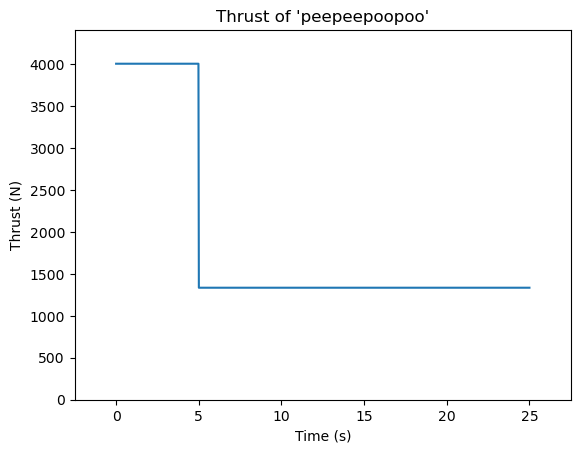

In [2]:
motor1 = TL.Motor("peepeepoopoo")

thrust = [900,300]
times = [5,25]
motor1.thrust_from_step_throttle(thrust, times)

motor1.plot_thrust()

Creating motor with name 'Spreadsheet Motor'
Auto-detected thrust in units of lbf


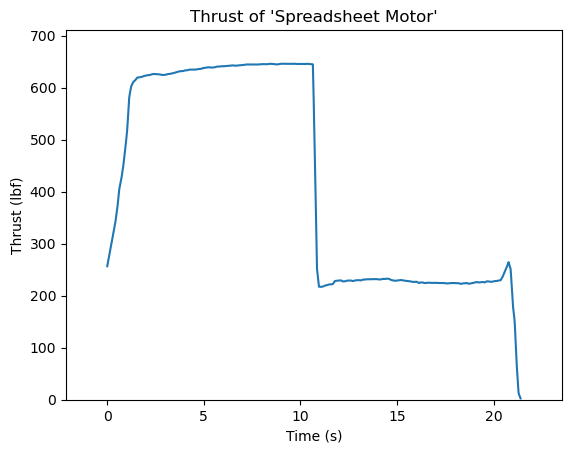

In [3]:
motor2 = TL.Motor("Spreadsheet Motor")


motor2.thrust_from_csv('test_motor.csv')

motor2.plot_thrust(units='lbf')


### Bodytube Testing



In [4]:
position = [0, 0, 35 * IN2M + 2] #m
length = 1.5 # m
density = 1750 #kg/m3 of carbon fiber
inner_diam = 7 * IN2M # inches
thickness = 0.096  * IN2M # inches
bt1 = TL.Bodytube(position, length, density, D_i = inner_diam, thickness=thickness, name="Bodytube 1")

position = [0, 0, 35 * IN2M] #m
length = 2 # m
density = 1750 #kg/m3 of carbon fiber
inner_diam = 7 * IN2M # inches
outer_diam = 7.192  * IN2M # inches
bt2 = TL.Bodytube(position, length, density, D_i = inner_diam, D_o=outer_diam, name="Bodytube 2")

In [5]:
print(f"Outer diameter: {bt1.mass * KG2LBM} lbm")
print(f"Outer diameter: {bt1.D_o * M2IN} in")
print(f"Inner diameter: {bt1.D_i * M2IN} in")
print(f"Length: {bt1.length * M2IN} in")
# print(bt1.mass)
# print(bt1.I_matrix)

Outer diameter: 7.990330210522773 lbm
Outer diameter: 7.192 in
Inner diameter: 7.0 in
Length: 59.05515 in


(-2.0, 2.0)

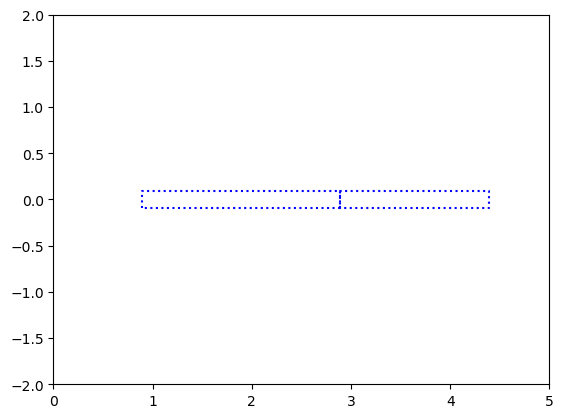

In [6]:
plt.plot(*bt1.points_2d, bt1.plot_fmt)
plt.plot(*bt2.points_2d, bt2.plot_fmt)
plt.xlim(0, 5)
plt.ylim(-2, 2)

### Nosecone Unit Testing

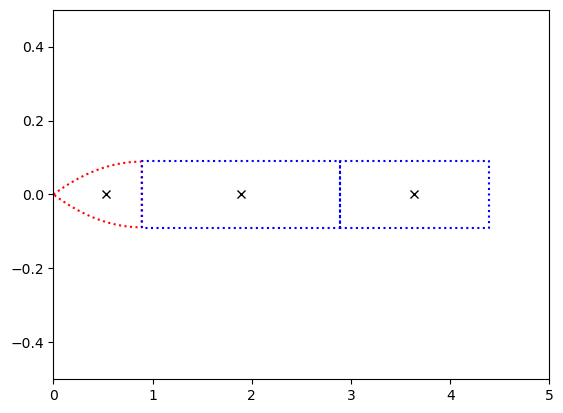

In [7]:
L = 35 * IN2M
d = 7 * IN2M
t = 0.035 * IN2M
mass = 3 * LBM2KG # lazy way out
nosecone1 = TL.Nosecone(length = L, shape = "ogive", D_o = d, thickness = t, name = "Nosey")

plt.plot(*nosecone1.points_2d, nosecone1.plot_fmt)
plt.plot(*bt1.points_2d, bt1.plot_fmt)
plt.plot(*bt2.points_2d, bt2.plot_fmt)
plt.xlim(0, 5)
plt.ylim(-0.5, 0.5)

bt2.plot_CG()
bt1.plot_CG()
nosecone1.plot_CG()

### Boattail Unit Testing

In [8]:
position = [0, 0, 35 * IN2M + 3.5] #m
density = 1750 #kg/m3 of carbon fiber
length = 11 * IN2M #m
rocket_diam = 7 * IN2M # m
inner_diam = 4.25 * IN2M # m
thickness = 0.06 * IN2M # m
tail = TL.Boattail(top_pos = position, length = length, density = density, thickness = thickness, D_front = rocket_diam, D_aft = inner_diam, name = "Tailey")

C_Na: -1.262755102040816


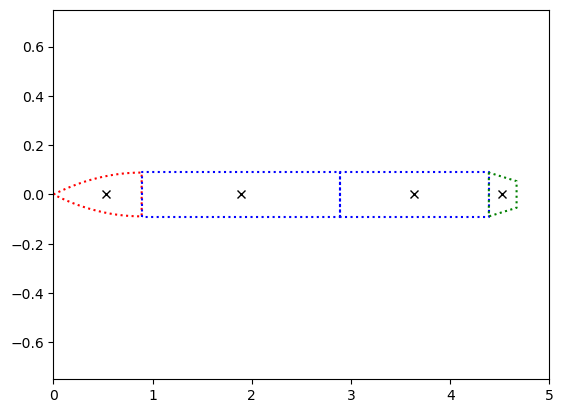

In [9]:
plt.plot(*nosecone1.points_2d, nosecone1.plot_fmt)
plt.plot(*bt1.points_2d, bt1.plot_fmt)
plt.plot(*bt2.points_2d, bt2.plot_fmt)
plt.plot(*tail.points_2d, tail.plot_fmt)
plt.xlim(0, 5)
plt.ylim(-0.75, 0.75)

bt2.plot_CG()
bt1.plot_CG()
nosecone1.plot_CG()
tail.plot_CG()

### Fin Unit Testing

In [10]:
Ct = 4 * IN2M
Cr = 14 * IN2M
span = 7.3 * IN2M
sweep_angle = 62.4611766504 # degrees
position = [0, 0, 46 * IN2M + 3.5 - Cr] #m
thickness = 0.42 * IN2M
density = 1750 #kg/m3 of carbon fiber

fin1 = TL.Fin(top_pos = position,
              span = span,
              thickness=thickness,
              Ct=Ct,
              Cr=Cr,
              roll_orientation=0,
              sweep_angle=sweep_angle,
              boattail_length=tail.length,
              rocket_diam=tail.D_front,
              aft_diam=tail.D_aft,
              name="Fin1",
              density=density)

fin2 = TL.Fin(top_pos = position,
              span = span,
              thickness=thickness,
              Ct=Ct,
              Cr=Cr,
              roll_orientation=120,
              sweep_angle=sweep_angle,
              boattail_length=tail.length,
              rocket_diam=tail.D_front,
              aft_diam=tail.D_aft,
              name="Fin2",
              density=density)

fin3 = TL.Fin(top_pos = position,
              span = span,
              thickness=thickness,
              Ct=Ct,
              Cr=Cr,
              roll_orientation=240,
              sweep_angle=sweep_angle,
              boattail_length=tail.length,
              rocket_diam=tail.D_front,
              aft_diam=tail.D_aft,
              name="Fin3",
              density=density)

[0.27093319 0.07554144]
fins longer
[0.27093319 0.07554144]
fins longer
[0.27093319 0.07554144]
fins longer


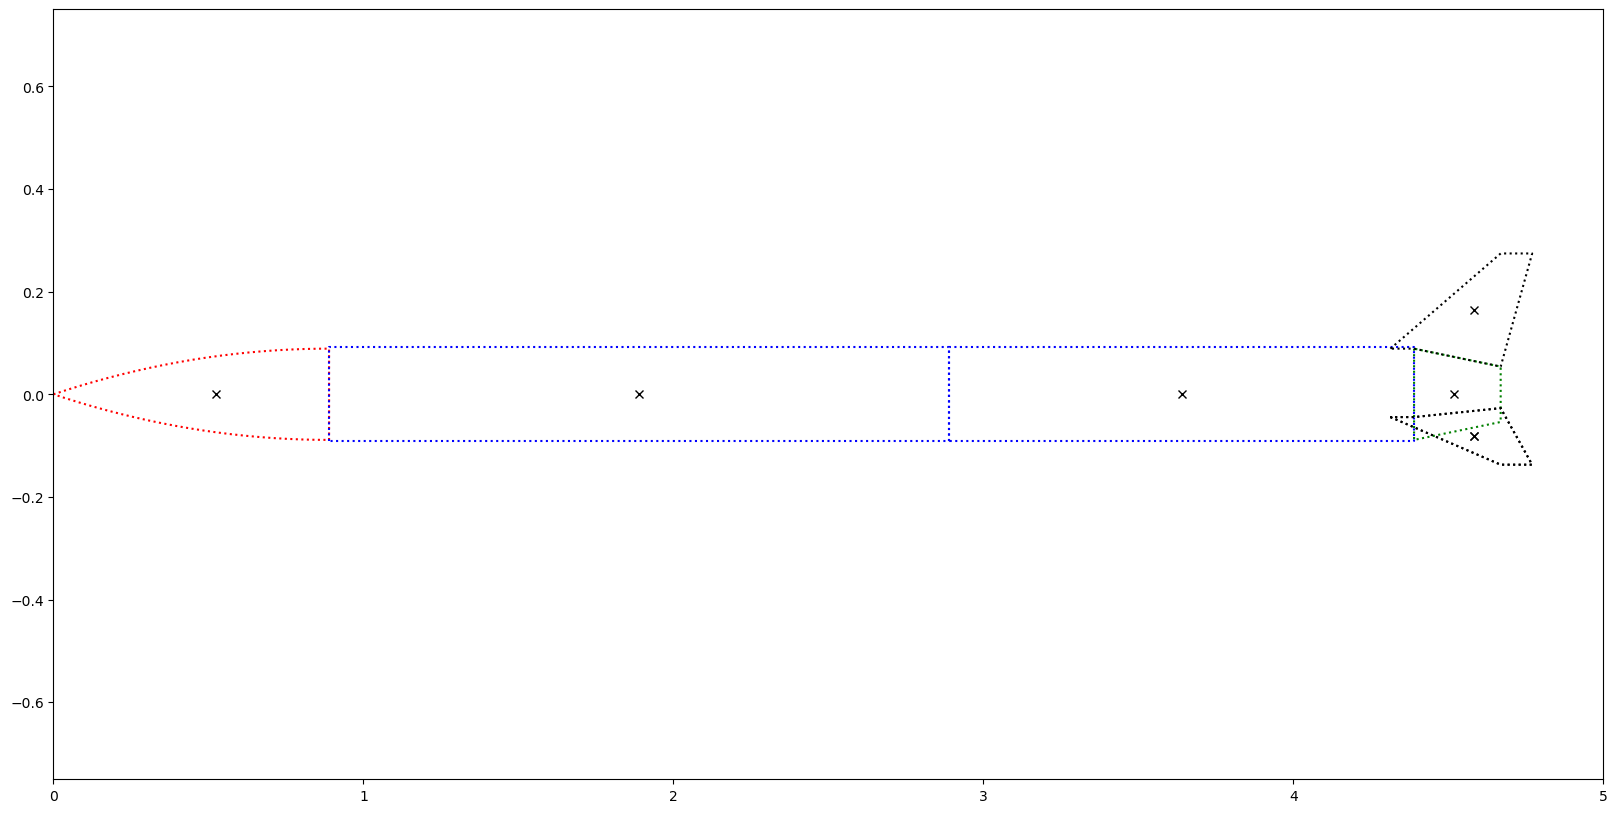

In [11]:
plt.figure(figsize=(20,10))
plt.plot(*nosecone1.points_2d, nosecone1.plot_fmt)
plt.plot(*bt1.points_2d, bt1.plot_fmt)
plt.plot(*bt2.points_2d, bt2.plot_fmt)
plt.plot(*tail.points_2d, tail.plot_fmt)
plt.plot(*fin1.points_2d, fin1.plot_fmt)
plt.plot(*fin2.points_2d, fin2.plot_fmt)
plt.plot(*fin3.points_2d, fin3.plot_fmt)
plt.xlim(0, 5)
plt.ylim(-0.75, 0.75)

bt2.plot_CG()
bt1.plot_CG()
nosecone1.plot_CG()
tail.plot_CG()
fin1.plot_CG()
fin2.plot_CG()
fin3.plot_CG()

### Fluid Unit Testing

In [12]:
density_ox = 1141 # kg/m3
density_fuel = 789 #kg/m3
of_ratio = 1.4
m_ox = (150 - 88) * (of_ratio / (of_ratio + 1)) * LBM2KG
m_f = (150 - 88) * (1 / (of_ratio + 1)) * LBM2KG

diameter = 6 * IN2M

top_pos_ox = np.array([0,0,2]) #m
top_pos_fuel = np.array([0,0,3]) #m
oxygen = TL.Fluid(top_pos=top_pos_ox, burn_time=motor2.tb, density=density_ox, wet_mass=m_ox, diameter=diameter, name = "Oxygen")
fuel = TL.Fluid(top_pos=top_pos_fuel, burn_time=motor2.tb, density=density_fuel, wet_mass=m_f, diameter=diameter, name = "Fuel")
# 28.1227 kg total prop

In [13]:
print(oxygen.I_matrix)
print(fuel.I_matrix)

print(oxygen.length * M2IN)
print(fuel.length * M2IN)

[[0.87309766 0.         0.        ]
 [0.         0.87309766 0.        ]
 [0.         0.         0.04762711]]
[[0.66428071 0.         0.        ]
 [0.         0.66428071 0.        ]
 [0.         0.         0.03401936]]
31.031035464498824
32.05360444051526


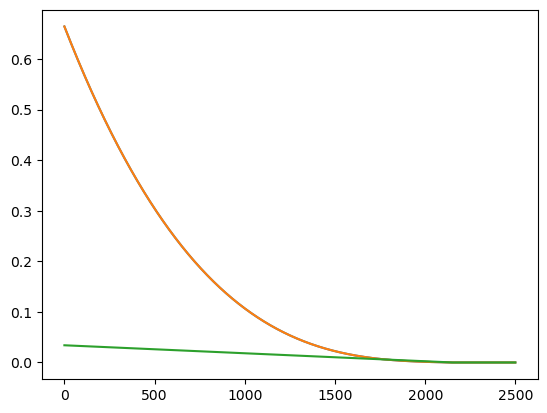

In [14]:
t = np.arange(0, 25, 0.01)

I = []
for i in range(len(t)):
    fuel.update(t[i])
    I.append(fuel.I_matrix)

I_x = [i[0][0] for i in I]
I_y = [i[1][1] for i in I]
I_z = [i[2][2] for i in I]

plt.plot(I_x)
plt.plot(I_y)
plt.plot(I_z)


(-0.75, 0.75)

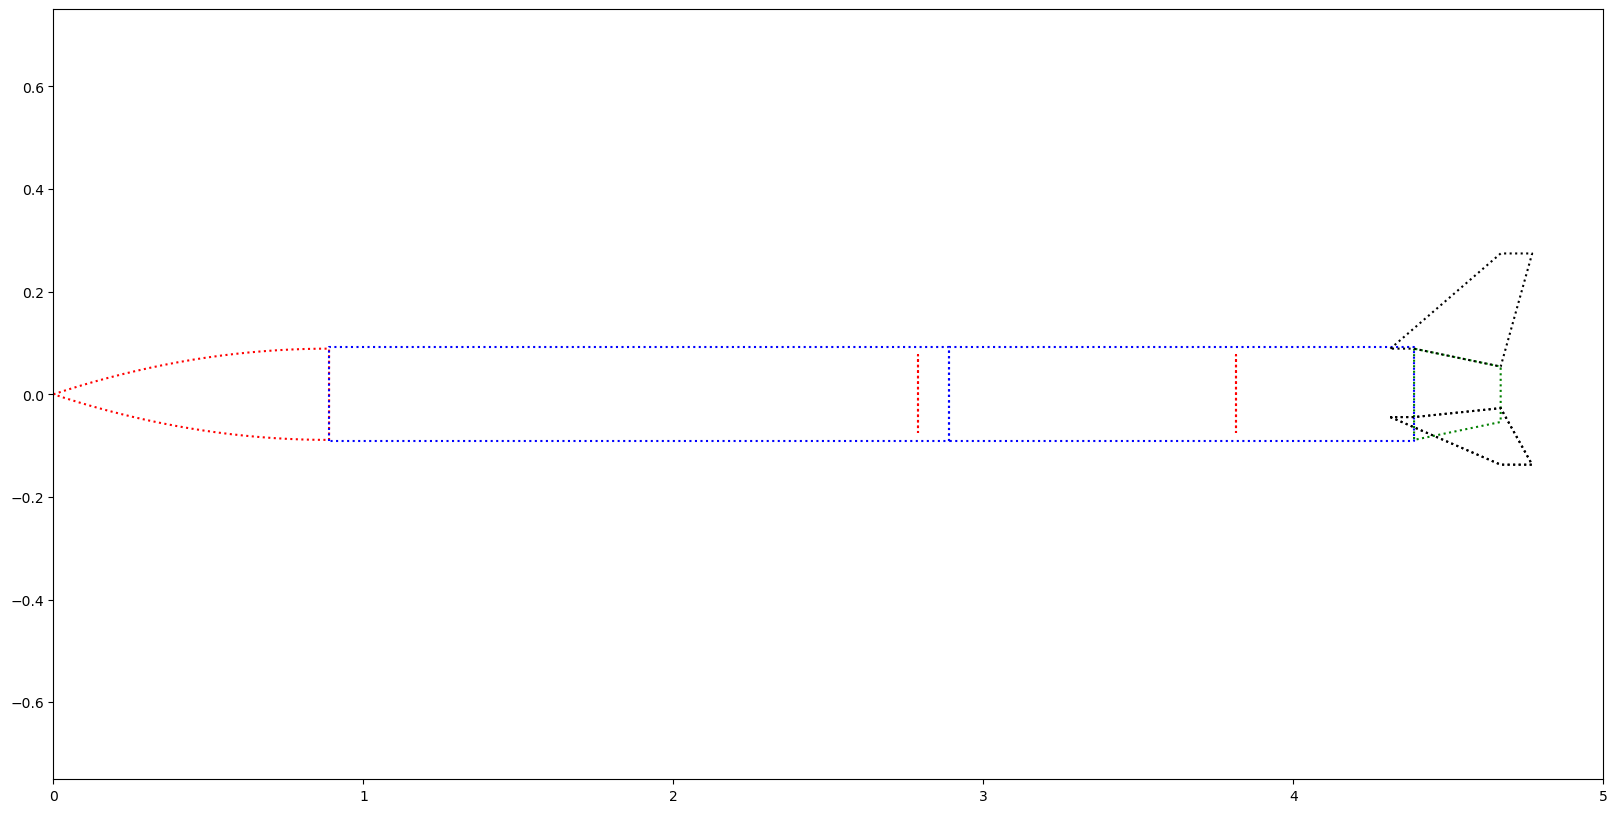

In [15]:
fuel.get_2d_points(100)
oxygen.get_2d_points(100)

plt.figure(figsize=(20,10))
plt.plot(*nosecone1.points_2d, nosecone1.plot_fmt)
plt.plot(*bt1.points_2d, bt1.plot_fmt)
plt.plot(*bt2.points_2d, bt2.plot_fmt)
plt.plot(*tail.points_2d, tail.plot_fmt)
plt.plot(*fin1.points_2d, fin1.plot_fmt)
plt.plot(*fin2.points_2d, fin2.plot_fmt)
plt.plot(*fin3.points_2d, fin3.plot_fmt)
plt.plot(*oxygen.points_2d, oxygen.plot_fmt)
plt.plot(*fuel.points_2d, fuel.plot_fmt)
plt.xlim(0, 5)
plt.ylim(-0.75, 0.75)


# bt2.plot_CG()
# bt1.plot_CG()
# nosecone1.plot_CG()
# tail.plot_CG()
# fin1.plot_CG()
# fin2.plot_CG()
# fin3.plot_CG()
# oxygen.plot_CG()
# fuel.plot_CG()

## Rocket Unit Testing

In [16]:
# mass = np.array([150, 88]) * LBM2KG
mass = np.array([73.731, 4.60E+01]) 

print(mass[0] - mass[1])
rocket = TL.Rocket(motor=motor2, name="Simple rocket", mass=mass)
rocket.initial_values()

rocket.add_nosecone(nosecone1)
rocket.add_bodytube(bt1)
rocket.add_bodytube(bt2)
rocket.add_boattail(tail)
rocket.add_fin(fin1)
rocket.add_fin(fin2)
rocket.add_fin(fin3)
rocket.add_fluid(oxygen)
rocket.add_fluid(fuel)


rocket.print_components()
# for i in rocket.airframe_list:
#     print(i.C_Na)

27.730999999999995
Simple rocket's Components:
--> Nosey
--> Bodytube 1
--> Bodytube 2
--> Tailey
--> Fin1
--> Fin2
--> Fin3
--> Oxygen
--> Fuel


In [17]:
numerator = 0
denomimator = 0

for i in rocket.airframe_list:
    numerator += i.CP_loc * i.C_Na
    denomimator += i.C_Na

CP = np.array(numerator/denomimator)

numerator = (rocket.CG_loc_dry * rocket.mass_dry)
numerator += fuel.CG_loc * fuel.mass + oxygen.CG_loc * oxygen.mass

denomimator = rocket.mass_dry + fuel.mass + oxygen.mass

print(numerator/denomimator)

CG = rocket.get_CG(0)
CP = rocket.get_CP(0)
print(CG)
print(CP)

[0.    0.    2.535]
[0.         0.         2.64167876]
[0.         0.         3.56622719]


length: 4.668399369064342
0.36354726736884524
2.535
2.6416787607269385
CP: 3.566227194362575


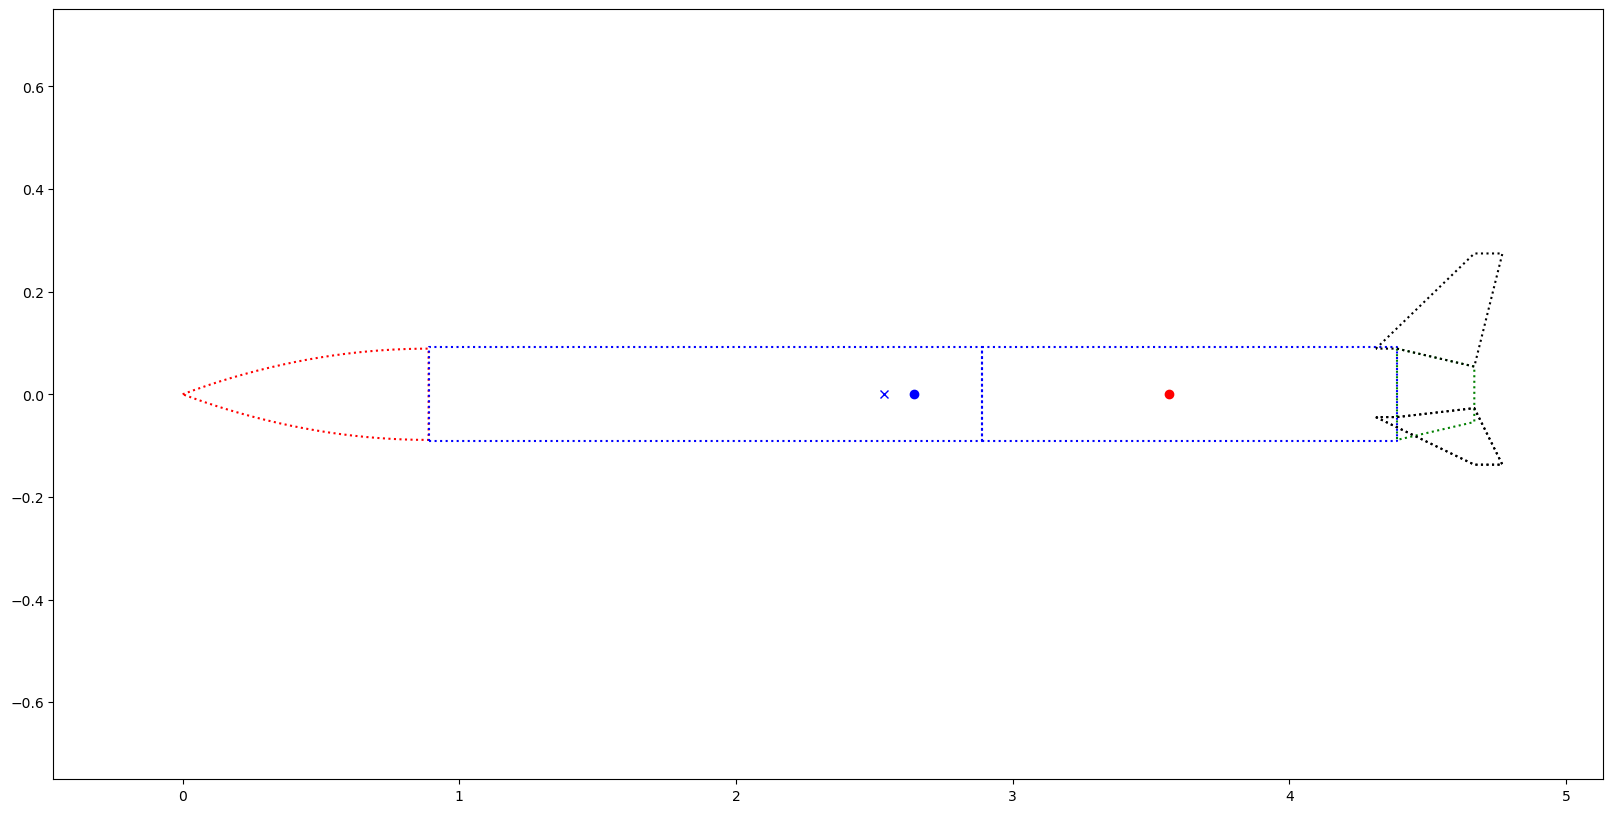

In [18]:
print(f"length: {rocket.length}") 

rocket.plot_airframe_components(cg=False)
plt.plot(CP[2],0, 'ro')
plt.plot(CG[2], 0, 'bo')
plt.plot(rocket.CG_loc_dry[2], 0, 'bx')

print((7/2 * IN2M)**2 * rocket.mass_dry)

print(rocket.CG_loc_dry[2])
print(CG[2])

print(f"CP: {CP[2]}")

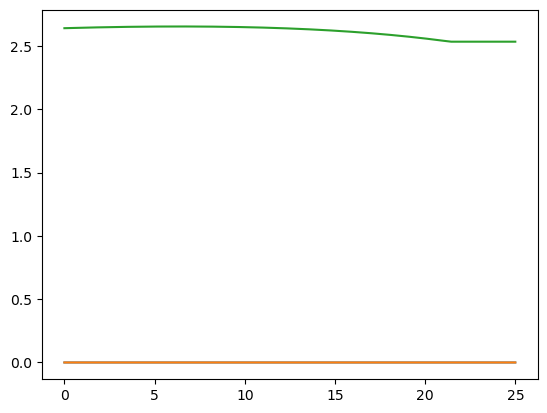

In [19]:
t = np.arange(0, 25, 0.01)

m = np.array([rocket.get_CG(i) for i in t])

plt.plot(t, m)

87.15373735495353

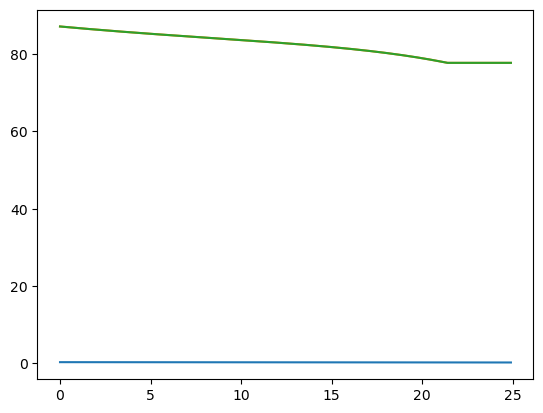

In [20]:
t = np.arange(0, 25, 0.1)

I = []
for i,time in enumerate(t):
    I_matrix = rocket.get_I_matrix(time)
    I.append(rocket.I_matrix)
    # break

# print(I)
# print(rocket.I_matrix_dry)
I_x = [i[0][0] for i in I]
I_y = [i[1][1] for i in I]
I_z = [i[2][2] for i in I]

# print(I[0][0])
plt.plot(t, I_z)
plt.plot(t, I_x)
plt.plot(t, I_y)

I_x[0]


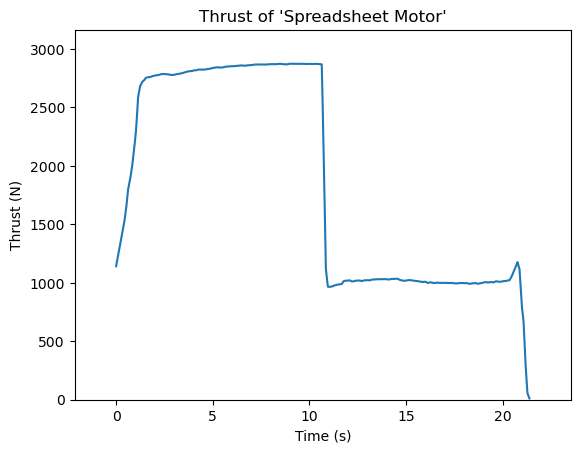

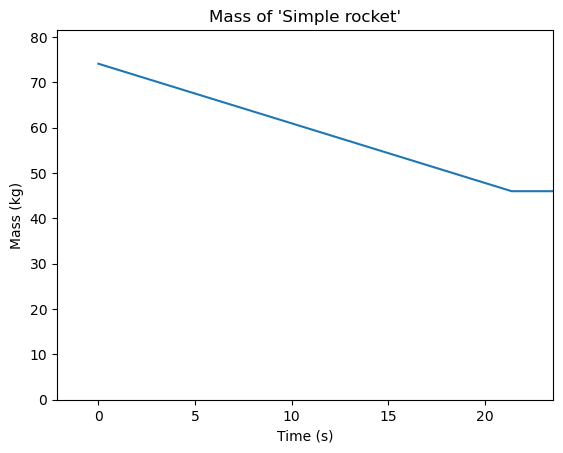

In [21]:
rocket.plot_thrust()
rocket.plot_mass()

Simple rocket's Components:
--> Nosey
--> Bodytube 1
--> Bodytube 2
--> Tailey
--> Fin1
--> Fin2
--> Fin3
--> Oxygen
--> Fuel


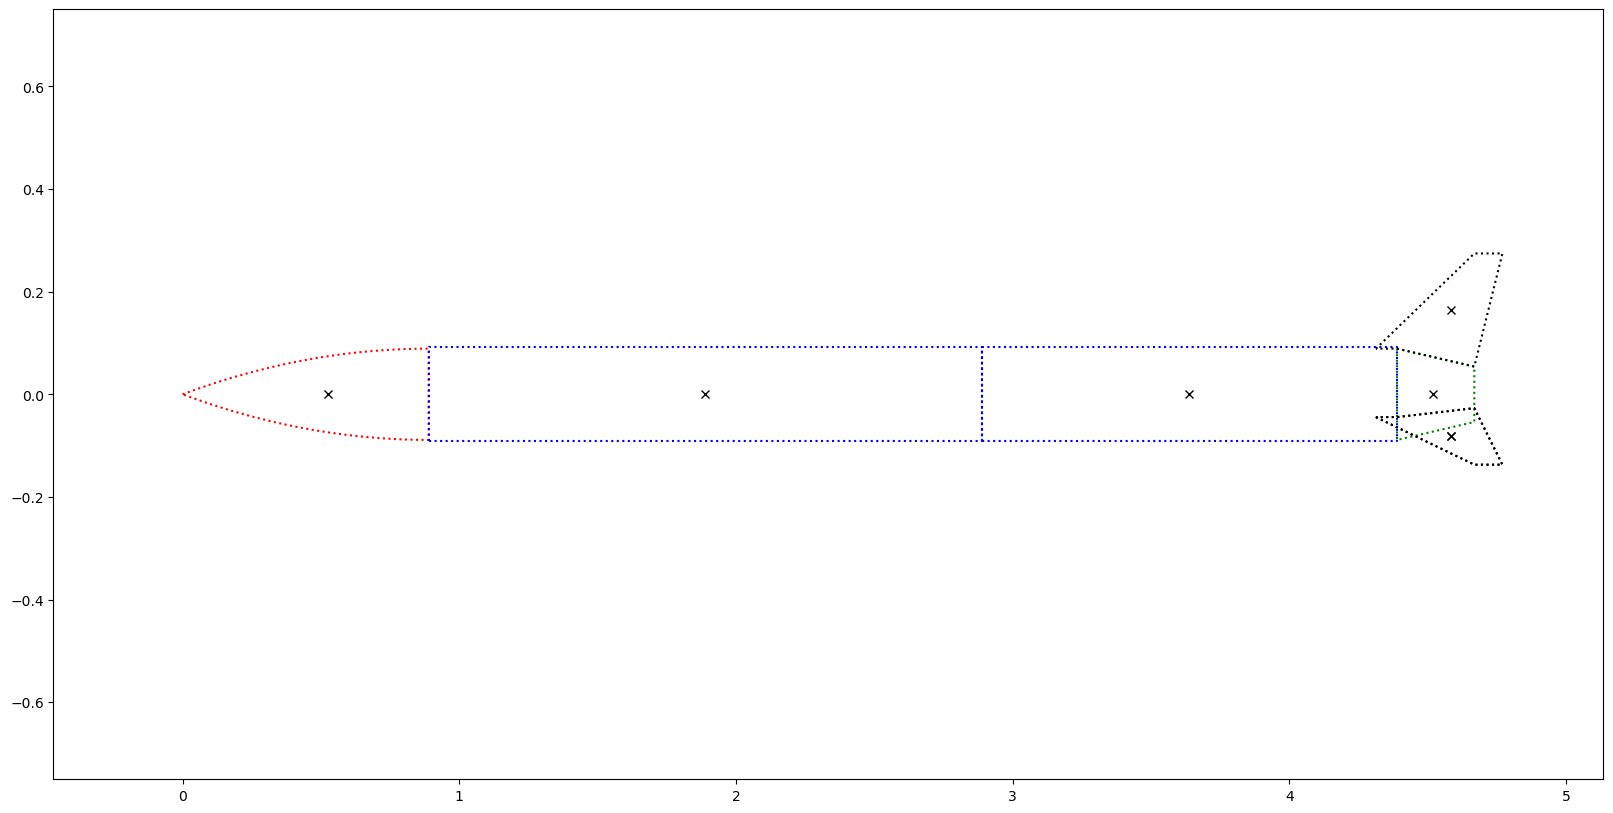

In [22]:
rocket.print_components()
rocket.plot_airframe_components()

# Drag test

## Skin friction drag

In [23]:
rocket.init_drag()

k_roughness = 0.00025
mach = 0.5
v_sound = 343 # m/s
nu = 1.81 * 10**(-5) # m2/s

# Rocket body around 0.003 
skin_fric_body = rocket.drag_object.skin_fric_coeff(rocket.length, k_roughness, mach, v_sound, nu)
print(skin_fric_body)

# Fins value around 0.0058
skin_fric_fins = rocket.drag_object.skin_fric_coeff(rocket.fins[0].Cr, k_roughness, mach, v_sound, nu)
print(skin_fric_fins)


Kb: 0.04146284892516855		n: 1.6754472982183284
0.00413039371873579
0.007344080581847613


In [24]:
print(rocket.bodytubes[0].wind_area)
print(rocket.nosecone.wind_area)
# print(rocket.nosecone.bruh)
# print(rocket.nosecone.length * np.pi * sum(rocket.nosecone.bruh))


0.8608436744363537
0.3243821625629836


In [25]:
params = {
    'wetted_area': rocket.wetted_area,
    'body_length': rocket.length,
    'max_body_diameter': rocket.max_body_diameter
}
print(params)
Cf_body = rocket.drag_object.friction_drag_coeff('body', skin_fric_body, params)

print(Cf_body)

{'wetted_area': 2.3330174029144755, 'body_length': 4.668399369064342, 'max_body_diameter': 0.18267670135458128}
0.39247727876494426


In [26]:

params = {
    'Cr': rocket.fins[0].Cr,
    'Ct': rocket.fins[0].Ct,
    'max_thickness': rocket.fins[0].thickness,
    'max_thickness_distance': rocket.fins[0].Cr / 2, # approximation
    'num_fins': 3,
    'fin_area': rocket.fins[0].wind_area,
    'Mach': mach,
    'v_sound': v_sound,
    'kinematic_viscosity': nu,
    'body_length': rocket.length,
    'max_body_diameter': rocket.max_body_diameter
}
print(params)
Cf_fins = rocket.drag_object.friction_drag_coeff('fins', skin_fric_body, params)


{'Cr': 0.3555998079761037, 'Ct': 0.10159994513602963, 'max_thickness': 0.01066799423928311, 'max_thickness_distance': 0.17779990398805184, 'num_fins': 3, 'fin_area': 0.08477393244412824, 'Mach': 0.5, 'v_sound': 343, 'kinematic_viscosity': 1.8100000000000003e-05, 'body_length': 4.668399369064342, 'max_body_diameter': 0.18267670135458128}


In [27]:
Cd_friction = 1.04*Cf_fins + Cf_body

print(Cd_friction)

0.4395504425452603


In [28]:
Cd_base = rocket.drag_object.base_drag_coeff(mach, Cd_friction)

print(Cd_base)

0.02590483523533798


In [29]:
print(rocket.drag_object.base_drag_Kb)

0.04146284892516855


# Environment Test

## Wind Speed Test

In [30]:
latitude = 35.34706755287037 
wind_speed = np.array([-27.1187, -11.1760])* FT2M
base_wind = TL.BaseWind(latitude=latitude,
            launch_site_wind= wind_speed)

Wind speed: [-8.2657795  -3.40644469]
l_MBL: 28.529331111112608 m
ABL Height: 973.4172137417753 m


[-0.30291205 -0.12483434]


Text(0.5, 0, 'altitude (m)')

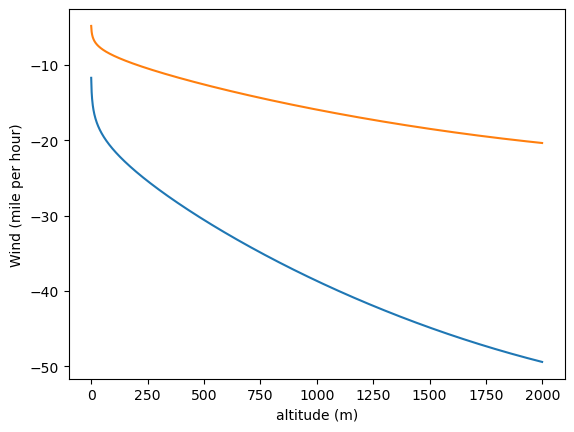

In [31]:
print(base_wind.u_star0)
# print(base_wind.launch_site_wind_speed)
winds = np.array([base_wind.update(alt = i*FT2M, rho = 1, vert_vel=1, prev_pressure_derivative=0)[0] for i in np.linspace(1,2000, 2000)])

# # print(winds[:,0].tolist())
plt.plot(winds[:,0] * M2FT * FT2MILE / SEC2HOUR)
plt.plot(winds[:,1] * M2FT * FT2MILE / SEC2HOUR)
plt.ylabel("Wind (mile per hour)")
plt.xlabel("altitude (m)")